# EXPERIMENT 5 – DATA VISUALIZATION USING MATPLOTLIB

## Aim
To create and analyze different types of charts such as Line Charts, Bar Charts, Pie Charts, Histograms, Scatter Plots, and Box Plots using Matplotlib with an IPL ball-by-ball dataset.

## Software Required
- Python 3.x
- Jupyter Notebook
- Pandas
- NumPy
- Matplotlib

## Theory
Data visualization represents data graphically so that trends, patterns, comparisons, distributions, and relationships can be identified easily. Matplotlib is a widely used Python library for creating static and customizable visualizations.

## Learning Outcomes
After completing this experiment, the student will be able to:
1. Create line, bar, pie, histogram, scatter, and box plots.
2. Compare IPL teams and seasons visually.
3. Analyze run distributions and relationships.
4. Customize charts with titles, labels, legends, and grids.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# The notebook first looks for the supplied IPL CSV in the current folder.
# If it is not present, place IPL_ball_by_ball_updated.csv beside this notebook.
file_candidates = [
    "IPL_ball_by_ball_updated.csv",
    "ipl_ball_by_ball_updated.csv"
]

csv_file = next((f for f in file_candidates if os.path.exists(f)), None)

if csv_file is None:
    raise FileNotFoundError(
        "IPL_ball_by_ball_updated.csv was not found. "
        "Place the CSV file in the same folder as this notebook."
    )

ipl = pd.read_csv(csv_file)

print("Dataset loaded successfully.")
print("Rows:", len(ipl))
print("Columns:", len(ipl.columns))
print("Seasons:", int(ipl["season"].min()), "to", int(ipl["season"].max()))
print("Shape:", ipl.shape)
ipl.head()


Dataset loaded successfully.
Rows: 243815
Columns: 22
Seasons: 2008 to 2023
Shape: (243815, 22)


,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,P Kumar,0,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Algorithm 1 – Line Chart
Display the total runs scored in each IPL season.

Season-wise total runs:
 season  total_runs
   2008       16809
   2009       15376
   2010       17753
   2011       19928
   2012       21323
   2013       21487
   2014       17943
   2015       17427
   2016       17962
   2017       17920
   2018       19098
   2019       18607
   2020       18566
   2021       17727
   2022       23052
   2023       24428


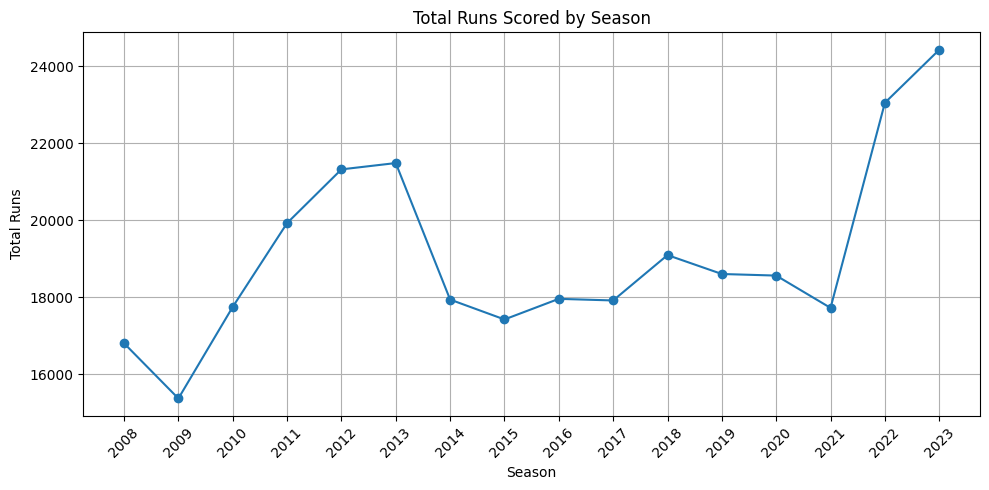

In [2]:
season_runs = (
    ipl.groupby("season")["runs_off_bat"]
       .sum()
       .reset_index(name="total_runs")
)

print("Season-wise total runs:")
print(season_runs.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.plot(season_runs["season"], season_runs["total_runs"], marker="o")
plt.title("Total Runs Scored by Season")
plt.xlabel("Season")
plt.ylabel("Total Runs")
plt.xticks(season_runs["season"], rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


## Algorithm 2 – Bar Chart
Display the 10 teams with the highest number of matches/innings appearances.

Top 10 teams by matches played:
team
Mumbai Indians                 247
Royal Challengers Bangalore    240
Kolkata Knight Riders          237
Chennai Super Kings            224
Rajasthan Royals               206
Kings XI Punjab                190
Sunrisers Hyderabad            166
Delhi Daredevils               161
Delhi Capitals                  77
Deccan Chargers                 75


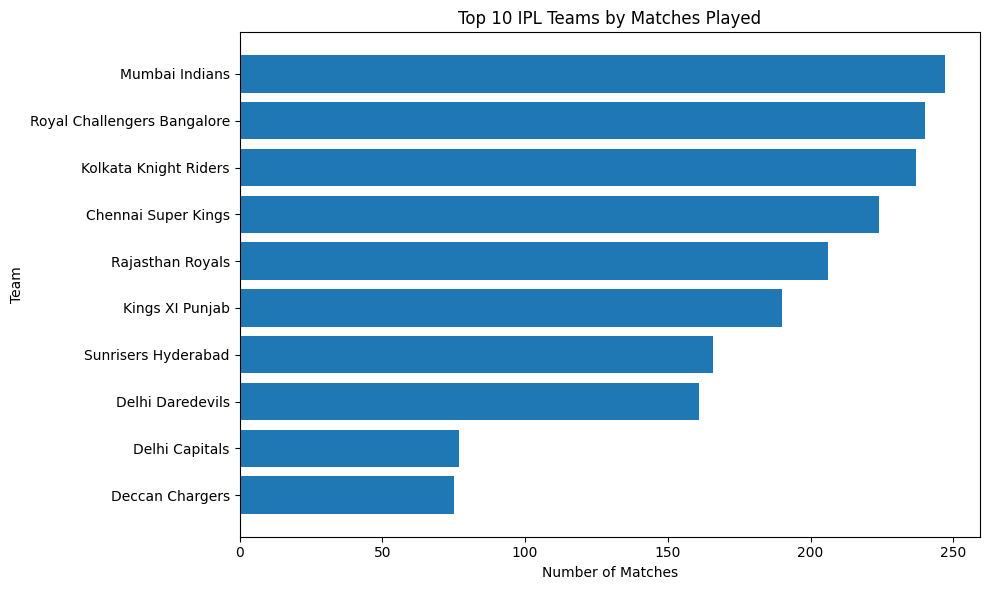

In [3]:
team_appearances = pd.concat([
    ipl[["match_id", "batting_team"]].rename(columns={"batting_team": "team"}),
    ipl[["match_id", "bowling_team"]].rename(columns={"bowling_team": "team"})
]).drop_duplicates()

top_teams = (
    team_appearances.groupby("team")["match_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

print("Top 10 teams by matches played:")
print(top_teams.sort_values(ascending=False).to_string())

plt.figure(figsize=(10, 6))
plt.barh(top_teams.index, top_teams.values)
plt.title("Top 10 IPL Teams by Matches Played")
plt.xlabel("Number of Matches")
plt.ylabel("Team")
plt.tight_layout()
plt.show()


## Algorithm 3 – Pie Chart
Show the share of match appearances among the six most frequent IPL teams.

Top 6 teams and match appearances:
team
Mumbai Indians                 247
Royal Challengers Bangalore    240
Kolkata Knight Riders          237
Chennai Super Kings            224
Rajasthan Royals               206
Kings XI Punjab                190


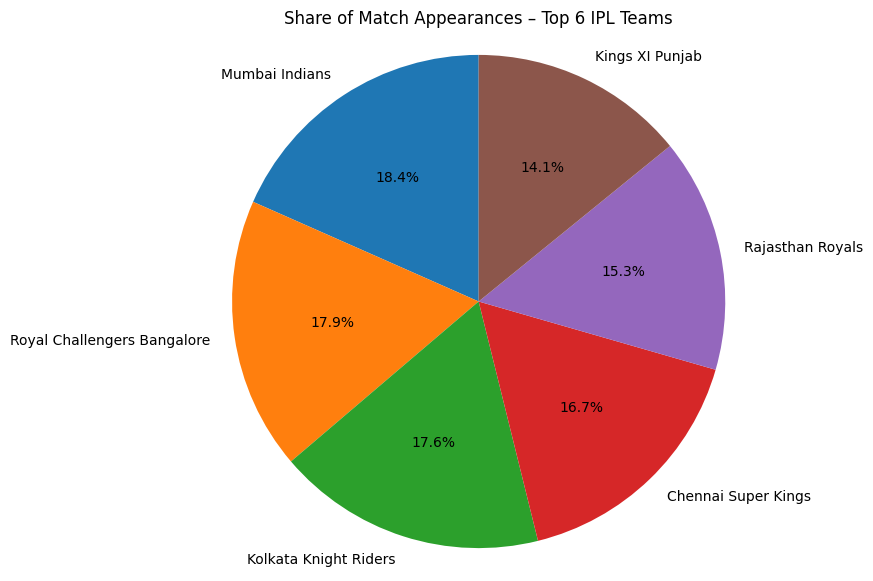

In [4]:
top6 = (
    team_appearances.groupby("team")["match_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(6)
)

print("Top 6 teams and match appearances:")
print(top6.to_string())

plt.figure(figsize=(7, 7))
plt.pie(top6.values, labels=top6.index, autopct="%1.1f%%", startangle=90)
plt.title("Share of Match Appearances – Top 6 IPL Teams")
plt.axis("equal")
plt.show()


## Algorithm 4 – Histogram
Display the frequency distribution of runs scored from the bat per delivery.

Runs per delivery – frequency table:
runs_off_bat
0    97544
1    90585
2    15406
3      753
4    27675
5       62
6    11790


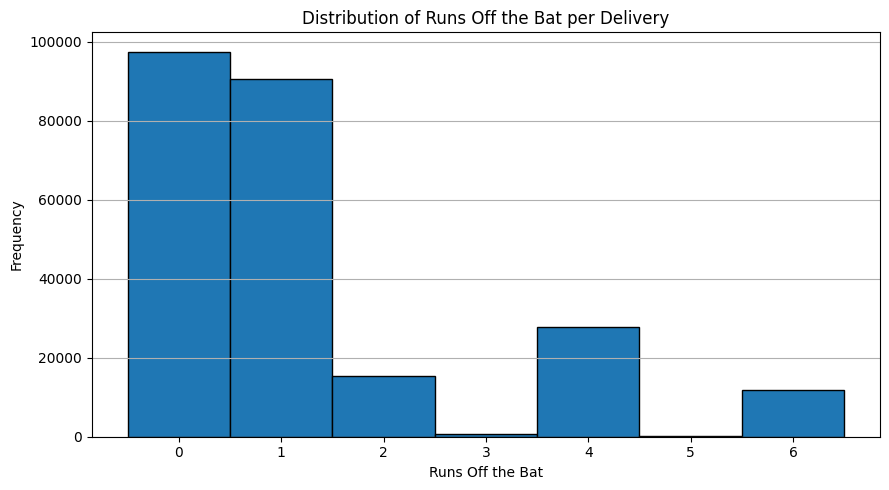

In [5]:
run_counts = ipl["runs_off_bat"].value_counts().sort_index()

print("Runs per delivery – frequency table:")
print(run_counts.to_string())

plt.figure(figsize=(9, 5))
plt.hist(ipl["runs_off_bat"], bins=np.arange(-0.5, 7.5, 1), edgecolor="black")
plt.title("Distribution of Runs Off the Bat per Delivery")
plt.xlabel("Runs Off the Bat")
plt.ylabel("Frequency")
plt.xticks(range(0, 7))
plt.grid(axis="y")
plt.tight_layout()
plt.show()


## Algorithm 5 – Scatter Plot
Analyze the relationship between runs scored by the striker and total runs recorded for the delivery.

First 10 observations used for the scatter plot:
 runs_off_bat  extras  total_runs
            0       1           1
            0       0           0
            0       1           1
            0       0           0
            0       0           0
            0       0           0
            0       1           1
            0       0           0
            4       0           4
            4       0           4

Correlation between runs off bat and total runs:
0.9778


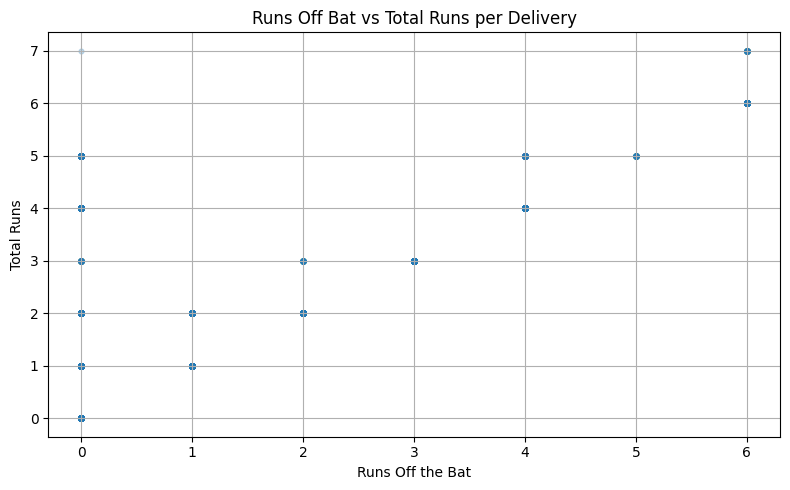

In [6]:
scatter_data = ipl[["runs_off_bat", "extras"]].copy()
scatter_data["total_runs"] = scatter_data["runs_off_bat"] + scatter_data["extras"]

print("First 10 observations used for the scatter plot:")
print(scatter_data.head(10).to_string(index=False))

print("\nCorrelation between runs off bat and total runs:")
print(round(scatter_data["runs_off_bat"].corr(scatter_data["total_runs"]), 4))

plt.figure(figsize=(8, 5))
plt.scatter(
    scatter_data["runs_off_bat"],
    scatter_data["total_runs"],
    alpha=0.25,
    s=12
)
plt.title("Runs Off Bat vs Total Runs per Delivery")
plt.xlabel("Runs Off the Bat")
plt.ylabel("Total Runs")
plt.grid(True)
plt.tight_layout()
plt.show()


## Algorithm 6 – Box Plot
Use a box plot to inspect the distribution and possible outliers of runs off the bat.

Descriptive statistics for runs off the bat:
count    243815.000000
mean          1.252614
std           1.626764
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           6.000000

Q1: 0.0
Q3: 1.0
IQR: 1.0
Lower bound: -1.5
Upper bound: 2.5
Number of outlier observations: 40280


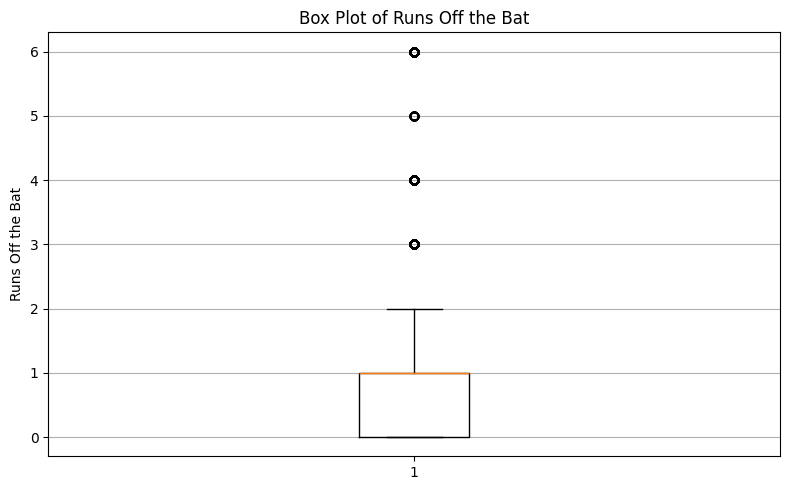

In [7]:
print("Descriptive statistics for runs off the bat:")
print(ipl["runs_off_bat"].describe().to_string())

q1 = ipl["runs_off_bat"].quantile(0.25)
q3 = ipl["runs_off_bat"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = ipl.loc[
    (ipl["runs_off_bat"] < lower) | (ipl["runs_off_bat"] > upper),
    "runs_off_bat"
]

print("\nQ1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower)
print("Upper bound:", upper)
print("Number of outlier observations:", len(outliers))

plt.figure(figsize=(8, 5))
plt.boxplot(ipl["runs_off_bat"].dropna(), vert=True)
plt.title("Box Plot of Runs Off the Bat")
plt.ylabel("Runs Off the Bat")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


## Algorithm 7 – Multiple Line Charts
Compare total runs and number of matches across IPL seasons.

Season-wise total runs and number of matches:
 season  total_runs  matches
   2008       16809       58
   2009       15376       57
   2010       17753       60
   2011       19928       73
   2012       21323       74
   2013       21487       76
   2014       17943       60
   2015       17427       59
   2016       17962       60
   2017       17920       59
   2018       19098       60
   2019       18607       60
   2020       18566       60
   2021       17727       60
   2022       23052       74
   2023       24428       74


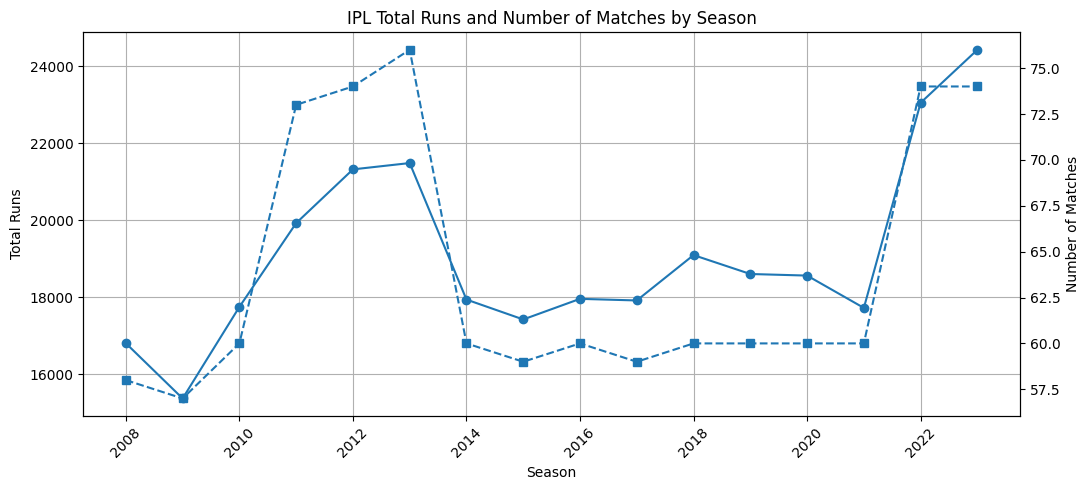

In [8]:
season_summary = (
    ipl.groupby("season")
       .agg(
           total_runs=("runs_off_bat", "sum"),
           matches=("match_id", "nunique")
       )
       .reset_index()
)

print("Season-wise total runs and number of matches:")
print(season_summary.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(
    season_summary["season"],
    season_summary["total_runs"],
    marker="o",
    label="Total Runs"
)
ax1.set_xlabel("Season")
ax1.set_ylabel("Total Runs")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(
    season_summary["season"],
    season_summary["matches"],
    marker="s",
    linestyle="--",
    label="Matches"
)
ax2.set_ylabel("Number of Matches")

plt.title("IPL Total Runs and Number of Matches by Season")
fig.tight_layout()
plt.show()


## Visualization Concepts

| Chart | Purpose |
|---|---|
| Line Chart | Shows trends across IPL seasons |
| Bar Chart | Compares teams/categories |
| Pie Chart | Shows percentage/share distribution |
| Histogram | Shows frequency distribution |
| Scatter Plot | Shows relationships between variables |
| Box Plot | Shows spread, median, and potential outliers |

## Applications
- Sports analytics
- Healthcare analytics
- Banking and finance
- Education
- Retail
- Social media analytics

## Advantages
- Simplifies complex data
- Helps faster decision making
- Identifies trends and patterns
- Makes comparisons easier
- Improves communication of analytical results

## Precautions
1. Select a chart type suitable for the data.
2. Provide clear titles and axis labels.
3. Verify the data before plotting.
4. Avoid misleading scales.
5. Interpret visual patterns carefully.


## Result

The IPL ball-by-ball dataset was successfully visualized using Matplotlib. Line, bar, pie, histogram, scatter, box, and multiple-line charts were created and analyzed successfully.
